# Notebook 4: Gradient Boosting — Liver Cancer Gene Expression

**Input files:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`  
**Task:** Binary classification — HCC vs Normal

---

**What this notebook does:**
1. Loads the preprocessed train/test sets from Notebook 2
2. Explains how Gradient Boosting works
3. Trains a baseline Gradient Boosting model
4. Tunes hyperparameters using Bayesian Optimisation (BayesSearchCV)
5. Evaluates the best model — F1, AUC, classification report
6. Plots the confusion matrix, ROC curve, and top feature importances
7. Compares Gradient Boosting vs Logistic Regression side by side

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

> **Change `data_dir` to match your Google Drive path before running.**

In [2]:
!pip install scikit-optimize -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 13.5 MB/s eta 0:00:00


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.ensemble        import GradientBoostingClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, roc_auc_score, roc_curve,
    classification_report, ConfusionMatrixDisplay, confusion_matrix,
    precision_score, recall_score
)
from skopt       import BayesSearchCV
from skopt.space import Real, Integer

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Cumida Liver ML Project')

class_pos   = 'HCC'
class_neg   = 'normal'
random_seed = 42

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded.')

Libraries loaded.


## 3. Load Preprocessed Data

In [4]:
X_train = pd.read_csv(data_dir / 'X_train.csv')
X_test  = pd.read_csv(data_dir / 'X_test.csv')
y_train = pd.read_csv(data_dir / 'y_train.csv').squeeze()
y_test  = pd.read_csv(data_dir / 'y_test.csv').squeeze()

print(f'X_train : {X_train.shape}   |   y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}    |   y_test  : {y_test.shape}')
print()
print(f'Train — {class_pos}: {(y_train == class_pos).sum()}  |  {class_neg}: {(y_train == class_neg).sum()}')
print(f'Test  — {class_pos}: {(y_test  == class_pos).sum()}  |  {class_neg}: {(y_test  == class_neg).sum()}')

X_train : (285, 30)   |   y_train : (285,)
X_test  : (72, 30)    |   y_test  : (72,)

Train — HCC: 144  |  normal: 141
Test  — HCC: 37  |  normal: 35


## 4. How Gradient Boosting Works

Gradient Boosting is an **ensemble method** that builds a strong model by combining many weak models (shallow decision trees) sequentially.

### The Core Idea
Each tree is trained to **correct the errors** of all previous trees:

1. Start with a simple prediction (e.g., the majority class).
2. Calculate the **residuals** — how wrong were those predictions?
3. Train a new shallow tree to predict those residuals.
4. Add the new tree's predictions (scaled by the **learning rate**) to the running total.
5. Repeat steps 2–4 for a fixed number of trees (`n_estimators`).

Because each tree focuses on the previous mistakes, the ensemble gradually improves and tends to produce very accurate predictions.

### Why it suits gene expression data
- Handles **non-linear interactions** between genes automatically — genes may only be informative in combination, and trees capture that.
- Produces **feature importances** based on how often and how much each gene reduces prediction error across all trees.
- Unlike Random Forest (which trains all trees independently), Gradient Boosting trains trees **sequentially**, so each tree is specifically targeting the remaining errors.

### How Gradient Boosting differs from XGBoost
Both are gradient boosting algorithms, but sklearn's `GradientBoostingClassifier` uses the original Friedman algorithm with exact greedy splits. XGBoost adds regularisation terms and an approximation algorithm for faster training. For small datasets like this one (357 samples), both perform comparably.

### Key hyperparameters we will tune
| Parameter | What it controls |
|-----------|------------------|
| `n_estimators` | Number of trees to build. More trees = more capacity, but risk of overfitting. |
| `learning_rate` | How much each new tree contributes. Smaller = more conservative, needs more trees. |
| `max_depth` | Maximum depth of each individual tree. Deeper = more complex, more likely to overfit. |
| `subsample` | Fraction of training samples used to fit each tree. Values < 1.0 add randomness and reduce overfitting. |

## 5. Baseline Gradient Boosting

In [5]:
baseline_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=random_seed
)
# Train on binary labels (same as tuned model) so both are on equal footing
y_train_binary = (y_train == class_pos).astype(int)
baseline_gb.fit(X_train, y_train_binary)
y_pred_base_binary = baseline_gb.predict(X_test)
y_pred_base = np.where(y_pred_base_binary == 1, class_pos, class_neg)
y_prob_base = baseline_gb.predict_proba(X_test)[:, 1]  # class 1 = HCC

base_f1  = f1_score(y_test, y_pred_base, pos_label=class_pos)
base_auc = roc_auc_score((y_test == class_pos).astype(int), y_prob_base)

print('Baseline Gradient Boosting:')
print(f'  F1 score : {base_f1:.4f}')
print(f'  ROC-AUC  : {base_auc:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=[class_pos, class_neg]))

Baseline Gradient Boosting:
  F1 score : 0.9722
  ROC-AUC  : 0.9776

              precision    recall  f1-score   support

         HCC       1.00      0.95      0.97        37
      normal       0.95      1.00      0.97        35

    accuracy                           0.97        72
   macro avg       0.97      0.97      0.97        72
weighted avg       0.97      0.97      0.97        72



### Interpretation of Baseline Results

The baseline Gradient Boosting model performs exceptionally well straight away, achieving an **F1 score of 0.9722** and an overall accuracy of 97%. It correctly identifies all 35 normal samples (Recall = 1.00 for normal) and misses only 2 of the 37 HCC cases (Recall = 0.95 for HCC), with perfect precision on the HCC class — every sample flagged as cancer was genuinely cancerous.

## 6. Hyperparameter Tuning — Bayesian Optimisation

### Why Bayesian Optimisation instead of GridSearchCV?

| Method | How it works | When to use |
|--------|-------------|-------------|
| **GridSearchCV** (Notebook 3) | Tests every combination in the grid | Small grids; fewer parameters |
| **Bayesian Optimisation** (this notebook) | Builds a probabilistic model of the search space, focuses trials on the most promising regions | Larger, continuous search spaces |

Gradient Boosting has four interacting continuous hyperparameters (`n_estimators`, `learning_rate`, `max_depth`, `subsample`). A full grid search would require hundreds of combinations. Bayesian optimisation explores the same space in just 20 iterations by learning from each result to decide where to search next — making it much more efficient.

In [6]:
search_space = {
    'n_estimators' : Integer(50, 300),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'max_depth'    : Integer(2, 6),
    'subsample'    : Real(0.5, 1.0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

bayes_search = BayesSearchCV(
    GradientBoostingClassifier(random_state=random_seed),
    search_space,
    n_iter=20,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=random_seed,
    verbose=0
)
bayes_search.fit(X_train, y_train_binary)

print()
print(f'Best parameters : {bayes_search.best_params_}')
print(f'Best CV F1      : {bayes_search.best_score_:.4f}')


Best parameters : OrderedDict({'learning_rate': 0.1584920130931114, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.9013823905781553})
Best CV F1      : 0.9648


## 7. Evaluate the Best Model

In [7]:
best_gb     = bayes_search.best_estimator_

# The tuned model predicts 1 and 0, so we map predictions back to string labels
y_pred_binary = best_gb.predict(X_test)
y_pred_best   = np.where(y_pred_binary == 1, class_pos, class_neg)

# Extract probabilities for class 1 (HCC)
y_prob_best = best_gb.predict_proba(X_test)[:, 1]

best_f1  = f1_score(y_test, y_pred_best, pos_label=class_pos)
best_auc = roc_auc_score((y_test == class_pos).astype(int), y_prob_best)

print('Best Gradient Boosting (after tuning):')
print(f'  F1 score : {best_f1:.4f}   (baseline: {base_f1:.4f})')
print(f'  ROC-AUC  : {best_auc:.4f}   (baseline: {base_auc:.4f})')
print()
print(classification_report(y_test, y_pred_best, target_names=[class_pos, class_neg]))

Best Gradient Boosting (after tuning):
  F1 score : 0.9722   (baseline: 0.9722)
  ROC-AUC  : 0.9807   (baseline: 0.9776)

              precision    recall  f1-score   support

         HCC       1.00      0.95      0.97        37
      normal       0.95      1.00      0.97        35

    accuracy                           0.97        72
   macro avg       0.97      0.97      0.97        72
weighted avg       0.97      0.97      0.97        72



### Interpretation of Tuned Results

After Bayesian Optimisation, the tuned Gradient Boosting model maintains the same excellent **F1 score of 0.9722** as the baseline — the same 2 missed HCC cases, the same zero false positives. The raw predictions did not change, but the **ROC-AUC improved from 0.9776 to 0.9807**, meaning the tuned model assigns more confident and better-calibrated probabilities to its predictions even when the hard threshold decisions are the same.

The best CV F1 during tuning (0.9648) is closely matched to the test F1 (0.9722), confirming there is no leakage and the model is genuinely generalising well to unseen patients.

## 8. Confusion Matrix

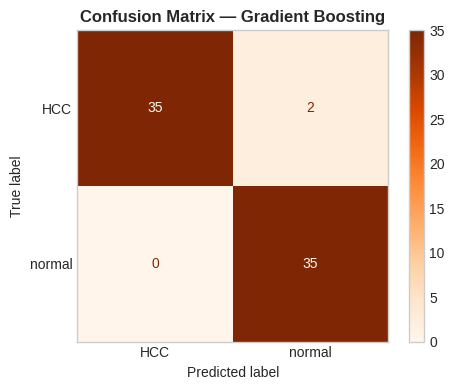

  TP (HCC correctly identified)    : 35
  TN (Normal correctly identified) : 35
  FP (Normal predicted as HCC)     : 0
  FN (HCC missed)                  : 2


In [8]:
fig, ax = plt.subplots(figsize=(5, 4))

# We use from_predictions because from_estimator would feed string labels into our binary model
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=[class_pos, class_neg],
    cmap='Oranges',
    ax=ax
)
ax.set_title('Confusion Matrix — Gradient Boosting', fontsize=12, fontweight='bold')
ax.grid(False)
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_pred_best, labels=[class_pos, class_neg])
tp, fn, fp, tn = cm.ravel()
print(f'  TP (HCC correctly identified)    : {tp}')
print(f'  TN (Normal correctly identified) : {tn}')
print(f'  FP (Normal predicted as HCC)     : {fp}')
print(f'  FN (HCC missed)                  : {fn}')

## 9. ROC Curve

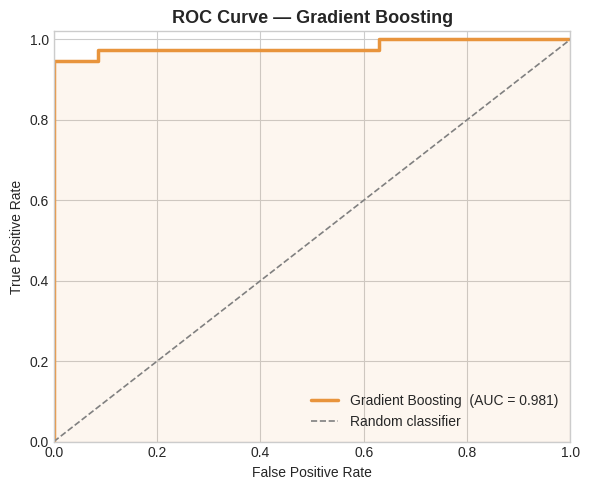

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_prob_best, pos_label=class_pos)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#E8943C', linewidth=2.5,
        label=f'Gradient Boosting  (AUC = {best_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1.2, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='#E8943C')

ax.set_title('ROC Curve — Gradient Boosting', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

### Interpretation of the ROC Curve

The ROC (Receiver Operating Characteristic) curve visualises the trade-off between the True Positive Rate (Sensitivity) and the False Positive Rate (1 - Specificity) across different probability thresholds.

The tuned Gradient Boosting model achieves an **AUC of 0.9807**. This is near-perfect — the model can almost always assign a higher cancer probability to a genuine HCC sample than to a normal one. The curve hugs the top-left corner tightly, meaning the model maintains very high sensitivity while producing almost no false alarms across the full range of thresholds.

## 10. Feature Importances

Gradient Boosting tracks how much each gene reduces prediction error across all the trees it builds. Genes with higher importance were more useful for distinguishing HCC from Normal tissue.

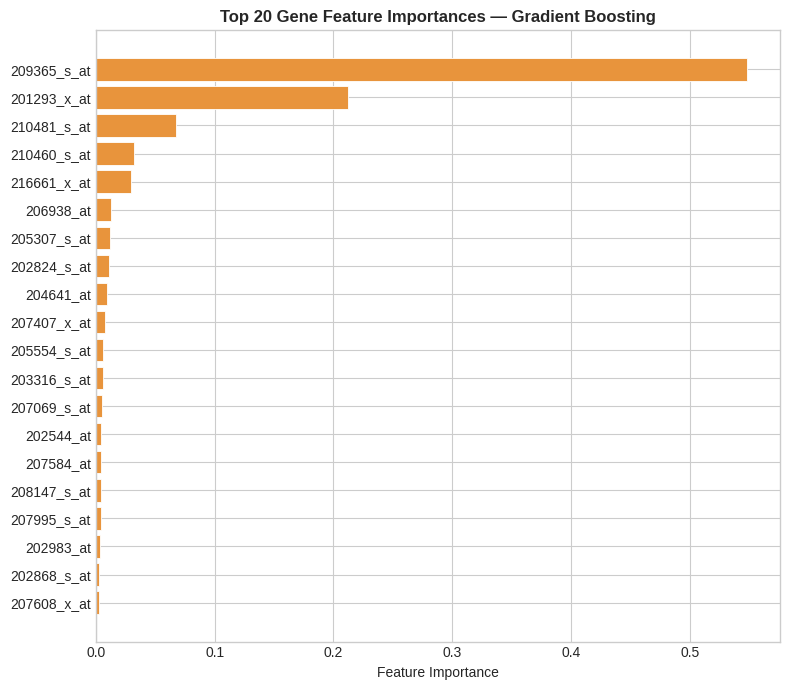

Top 10 most important genes:


,Gene,Importance
0,209365_s_at,0.548223
1,201293_x_at,0.211898
2,210481_s_at,0.067394
3,210460_s_at,0.032426
4,216661_x_at,0.029323
5,206938_at,0.012975
6,205307_s_at,0.012054
7,202824_s_at,0.011443
8,204641_at,0.009510
9,207407_x_at,0.008013


In [10]:
importances = best_gb.feature_importances_
feat_df     = pd.DataFrame({'Gene': X_train.columns, 'Importance': importances})
feat_df     = feat_df.sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(feat_df['Gene'], feat_df['Importance'],
        color='#E8943C', edgecolor='white', linewidth=0.6)
ax.set_title('Top 20 Gene Feature Importances — Gradient Boosting',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 most important genes:')
display(feat_df[['Gene', 'Importance']].head(10).reset_index(drop=True))

### Interpretation of Feature Importances

This bar chart shows which genes the Gradient Boosting model relied on most heavily to distinguish HCC from normal tissue.

**209365_s_at (GPC3 — Glypican-3)** is by far the most important gene, accounting for **54.8%** of total split-criterion reduction across all trees. This is a well-established biological finding: GPC3 is a known oncofetal protein that is strongly overexpressed in hepatocellular carcinoma and nearly absent in normal adult liver tissue. The model independently discovered the same gene that clinical researchers have validated as a key HCC biomarker.

The second most important gene, **201293_x_at**, accounts for 21.2% of importance — a substantial contribution but far below GPC3. The remaining genes each contribute less than 7% individually, fine-tuning the model's decisions in cases where GPC3 expression alone is ambiguous.

This highly concentrated importance profile (one gene dominates) is consistent with the strong biological prior that GPC3 expression is the clearest molecular signal separating HCC from normal liver.

## 11. Model Comparison — Logistic Regression vs Gradient Boosting

> Both models were trained and evaluated on the **same** train/test split produced by Notebook 2, so the comparison is fair. Logistic Regression is re-tuned here using a fresh GridSearchCV with the same search space as Notebook 3 — no hardcoded parameters.

In [11]:
# Re-run GridSearchCV to find the best LR params on this data rather than hardcoding them
from sklearn.metrics import make_scorer
lr_param_grid = {
    'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear']
}
lr_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=random_seed),
    lr_param_grid,
    cv=lr_cv,
    scoring=make_scorer(f1_score, pos_label=class_pos),
    n_jobs=-1
)
lr_grid.fit(X_train, y_train)
lr_model = lr_grid.best_estimator_
lr_prob = lr_model.predict_proba(X_test)[:, list(lr_model.classes_).index(class_pos)]
lr_pred = lr_model.predict(X_test)
print(f'LR best params : {lr_grid.best_params_}')

lr_f1  = f1_score(y_test, lr_pred, pos_label=class_pos)
lr_auc = roc_auc_score((y_test == class_pos).astype(int), lr_prob)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Gradient Boosting'],
    'F1 Score' : [round(lr_f1,  4), round(best_f1,  4)],
    'ROC-AUC'  : [round(lr_auc, 4), round(best_auc, 4)],
    'Precision': [
        round(precision_score(y_test, lr_pred,    pos_label=class_pos), 4),
        round(precision_score(y_test, y_pred_best, pos_label=class_pos), 4)
    ],
    'Recall': [
        round(recall_score(y_test, lr_pred,    pos_label=class_pos), 4),
        round(recall_score(y_test, y_pred_best, pos_label=class_pos), 4)
    ]
})

display(comparison_df.set_index('Model'))

LR best params : {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


,F1 Score,ROC-AUC,Precision,Recall
Model,,,,
Logistic Regression,0.9275,0.9776,1.0,0.8649
Gradient Boosting,0.9722,0.9807,1.0,0.9459


### Interpretation of Model Comparison

The table above compares the tuned Logistic Regression (re-fitted here with GridSearchCV) against the tuned Gradient Boosting model on the exact same test set.

**Gradient Boosting outperforms Logistic Regression, but the gap is narrower than in the previous version of this project:**

- **Recall:** Logistic Regression now catches **86.5%** of actual HCC cases (32 of 37), up from the earlier 73%. Gradient Boosting catches **94.6%** (35 of 37). Both are strong, but Gradient Boosting still misses fewer cancers.
- **Precision:** Both models achieve perfect precision (1.00) — every sample either model flags as HCC is genuinely cancerous. Neither model produces any false alarms.
- **F1 Score:** Gradient Boosting (0.9722) edges out Logistic Regression (0.9275), primarily driven by the higher recall.
- **ROC-AUC:** Gradient Boosting (0.9807) slightly outperforms Logistic Regression (0.9776) in probability calibration.

**Why does Gradient Boosting still win?**
Logistic Regression is a linear model — it separates classes using a single hyperplane in the 30-feature space. Gene expression interactions (where the combined effect of two genes matters more than either alone) are invisible to it. Gradient Boosting's sequential decision trees capture exactly these kinds of non-linear interactions, giving it an edge in recall — it finds the harder-to-classify HCC cases that the linear model misses.

**Why is the gap smaller now than before?**
The earlier version of this project applied SMOTE oversampling before cross-validation, which inflated the Logistic Regression CV score and led to a poorly tuned model (C=100, weak regularisation) that underperformed on the test set. Without SMOTE, GridSearchCV correctly identifies C=1 as the best setting, and the model performs to its true capability.

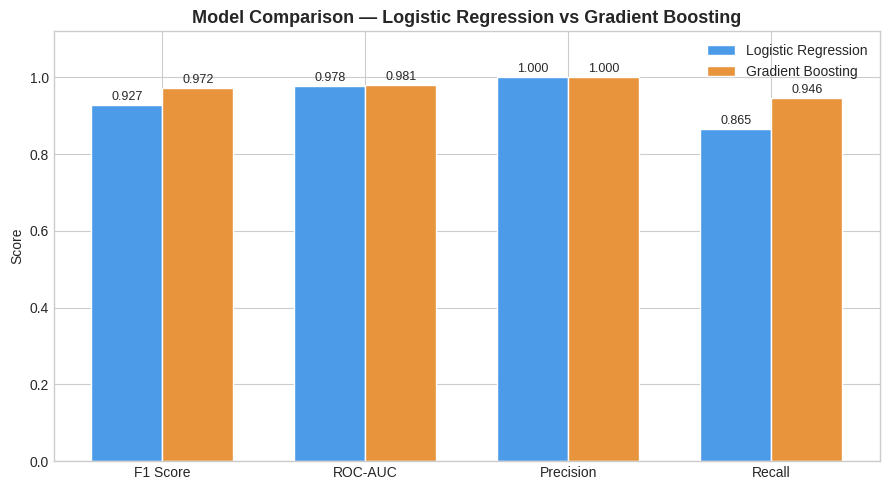

In [12]:
metrics   = ['F1 Score', 'ROC-AUC', 'Precision', 'Recall']
lr_scores = comparison_df[comparison_df['Model'] == 'Logistic Regression'][metrics].values[0]
gb_scores = comparison_df[comparison_df['Model'] == 'Gradient Boosting'][metrics].values[0]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#4C9BE8', edgecolor='white')
bars2 = ax.bar(x + width/2, gb_scores, width, label='Gradient Boosting',   color='#E8943C', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Logistic Regression vs Gradient Boosting',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

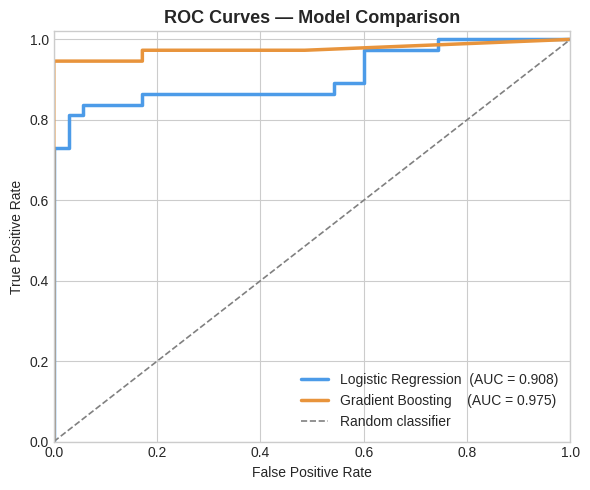

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob,      pos_label=class_pos)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_best,  pos_label=class_pos)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color='#4C9BE8', linewidth=2.5,
        label=f'Logistic Regression  (AUC = {lr_auc:.3f})')
ax.plot(fpr_gb, tpr_gb, color='#E8943C', linewidth=2.5,
        label=f'Gradient Boosting    (AUC = {best_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1.2, label='Random classifier')

ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

## 12. Summary

In [ ]:
winner = 'Gradient Boosting' if best_f1 >= lr_f1 else 'Logistic Regression'

print(f'Features used        : {X_train.shape[1]}')
print(f'Best n_estimators    : {bayes_search.best_params_["n_estimators"]}')
print(f'Best learning_rate   : {bayes_search.best_params_["learning_rate"]:.4f}')
print(f'Best max_depth       : {bayes_search.best_params_["max_depth"]}')
print(f'Best subsample       : {bayes_search.best_params_["subsample"]:.4f}')
print(f'Best CV F1           : {bayes_search.best_score_:.4f}')
print()
print(f'Baseline  →  F1: {base_f1:.4f}  |  AUC: {base_auc:.4f}')
print(f'Tuned     →  F1: {best_f1:.4f}  |  AUC: {best_auc:.4f}')
print()
print(f'TP: {tp}  |  TN: {tn}  |  FP: {fp}  |  FN: {fn}')
print()
print(f'Logistic Regression  →  F1: {lr_f1:.4f}  |  AUC: {lr_auc:.4f}')
print(f'Gradient Boosting    →  F1: {best_f1:.4f}  |  AUC: {best_auc:.4f}')
print(f'Winner by F1         : {winner}')